In [1]:
import numpy as np
import pandas as pd



In [2]:
url_train = "https://raw.githubusercontent.com/ben519/nnets-for-your-dog/master/data/mnist_train.csv"

# Load the training data
df = pd.read_csv(url_train)
# Checking data shape to confirm it loaded (should be 42000 images, 785 columns)
print(df.shape)

(50000, 785)


In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


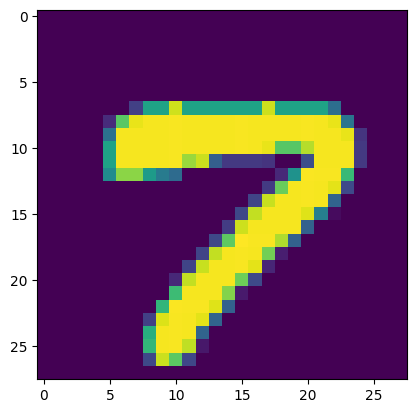

In [4]:
import matplotlib.pyplot as plt

# Slicing a random row (e.g. index 13515), skipping the label at column 0, and extracting .values
plt.imshow(df.iloc[13515, 1:].values.reshape(28, 28))

In [5]:
# Setting features (X) by excluding label, and target labels (y)
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Train-test split (80% training, 20% validation)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape

(40000, 784)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

# Track execution time due to high dimensions
import time
start = time.time()

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(time.time() - start)

6.60711145401001


In [7]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9675

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.decomposition import PCA
# Instantiating PCA with 100 components
pca = PCA(n_components=100)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

# Verify compressed matrix layout
X_train_trf.shape

(40000, 100)

In [10]:
knn = KNeighborsClassifier()

knn.fit(X_train_trf, y_train)
y_pred = knn.predict(X_test_trf)

# Checking performance output
accuracy_score(y_test, y_pred)

0.9583

In [11]:
for i in range(1, 785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)
    
    print(accuracy_score(y_test, y_pred))

0.2563
0.3188
0.504
0.6645
0.7345
0.818
0.8326
0.868
0.8845
0.9036
0.9135
0.9196
0.928
0.9337
0.9375
0.9411
0.9414
0.9425
0.9449


KeyboardInterrupt: 

In [12]:
import plotly.express as px

pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)

# Converting class to string configuration for Plotly's tracking color markers
y_train_str = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:, 0], y=X_train_trf[:, 1], color=y_train_str)
fig.show()

In [13]:
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)

fig = px.scatter_3d(x=X_train_trf[:, 0], y=X_train_trf[:, 1], z=X_train_trf[:, 2], color=y_train_str)
fig.show()

In [14]:
pca = PCA(n_components=3)
pca.fit_transform(X_train)

# Explained variance values (Eigenvalues / Lambdas)
pca.explained_variance_

# Component vector geometry shapes (Eigenvectors array)
pca.components_.shape

(3, 784)

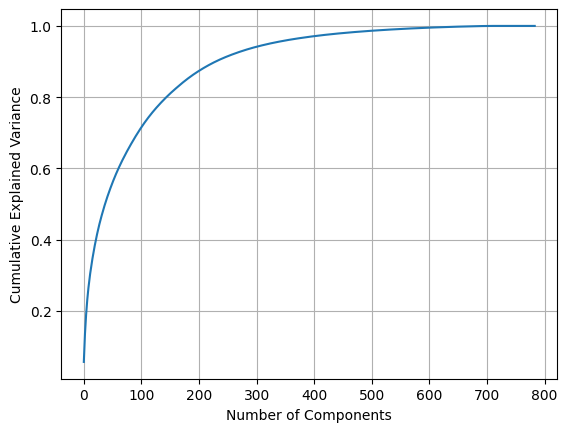

In [15]:
pca = PCA(n_components=None)
pca.fit_transform(X_train)

# Finding variance percent distribution profiles
pca.explained_variance_ratio_

# Computing cumulative running variance sum
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

# Plotting the curve profile 
plt.plot(cumulative_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()